In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/job_postings_tech_with_seniority.csv")
print(df.columns)
print(df["seniority"].value_counts())

Index(['title', 'description', 'experience', 'qualifications',
       'responsibilities', 'preference', 'text', 'clean_text',
       'embedding_text', 'seniority'],
      dtype='object')
seniority
mid           173904
entry         130834
senior         68001
leadership     20937
Name: count, dtype: int64


In [3]:
TEXT_COL = "embedding_text"

In [4]:
# words — sourced from Gaucher et al. (2011)

masculine_words = {
    "active","adventurous","aggressive","ambitious","analytical","assertive",
    "athletic","autonomous","battle","boast","challenge","champion",
    "competitive","confident","courageous","decide","decision","decisive",
    "determine","dominant","driven","fearless","force","headstrong",
    "independent","individual","intellectual","lead","leader","leadership",
    "logic","objective","opinion","outspoken","persistent","principled",
    "self_confident","self_reliant","strong","superior","strategic",
    "visionary","directive","authoritative","command","control",
    "results","achievement","ambition","initiative","risk","win",
    "performance","expert","skilled","specialist","technical",
    "architect","design","build","innovate","optimize","scale",
    "execute","deliver","ownership","impact"
}

feminine_words = {
    "agree","affectionate","collaborate","commit","communal","compassionate",
    "connect","considerate","cooperate","dependable","emotional","empathic",
    "feel","gentle","honest","interpersonal","kind","loyal","modest",
    "nurture","pleasant","polite","quiet","sensitive","submissive",
    "support","sympathetic","tender","together","trust","understand",
    "warm","sharing","helpful","caring","collaboration","communication",
    "community","team","teamwork","assist","facilitate","mentor",
    "guide","encourage","enable","relationship","inclusive",
    "cooperative","partnership","engagement","listen","respect",
    "responsive","adaptable","flexible","approachable"
}

In [5]:
def tokenize(text):
    text = str(text or "").lower()
    return re.findall(r"[a-z_]+", text)

def coded_counts(text, masc_set, fem_set):
    tokens = tokenize(text)
    masc = sum(1 for t in tokens if t in masc_set)
    fem = sum(1 for t in tokens if t in fem_set)
    total = len(tokens)
    return pd.Series({
        "masc_count": masc,
        "fem_count": fem,
        "total_tokens": total
    })

df[["masc_count", "fem_count", "total_tokens"]] = df[TEXT_COL].apply(
    lambda x: coded_counts(x, masculine_words, feminine_words)
)

In [6]:
summary = (
    df.groupby("seniority")[["masc_count", "fem_count", "total_tokens"]]
    .sum()
    .reset_index()
)

summary["masc_per_1000"] = summary["masc_count"] / summary["total_tokens"] * 1000
summary["fem_per_1000"] = summary["fem_count"] / summary["total_tokens"] * 1000
summary["bias_score"] = summary["masc_per_1000"] - summary["fem_per_1000"]

summary

,seniority,masc_count,fem_count,total_tokens,masc_per_1000,fem_per_1000,bias_score
0,entry,275158,111904,6619678,41.566674,16.904750,24.661925
1,leadership,39149,7009,891348,43.921117,7.863371,36.057746
2,mid,368067,156384,8913977,41.290997,17.543684,23.747313
3,senior,147258,61938,3487711,42.221962,17.758926,24.463036


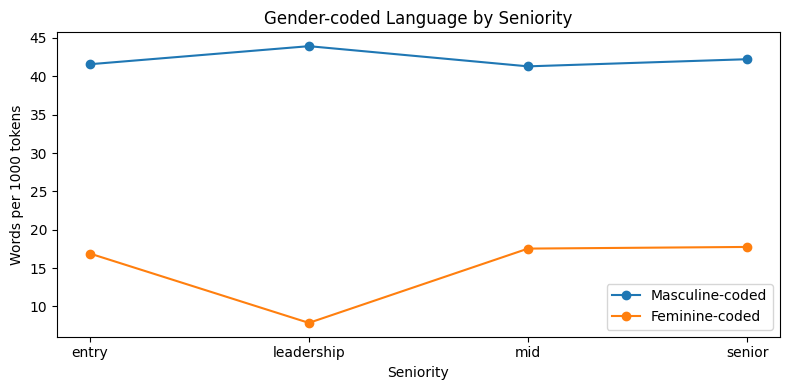

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(summary["seniority"], summary["masc_per_1000"], marker="o", label="Masculine-coded")
plt.plot(summary["seniority"], summary["fem_per_1000"], marker="o", label="Feminine-coded")
plt.title("Gender-coded Language by Seniority")
plt.xlabel("Seniority")
plt.ylabel("Words per 1000 tokens")
plt.legend()
plt.tight_layout()
plt.show()

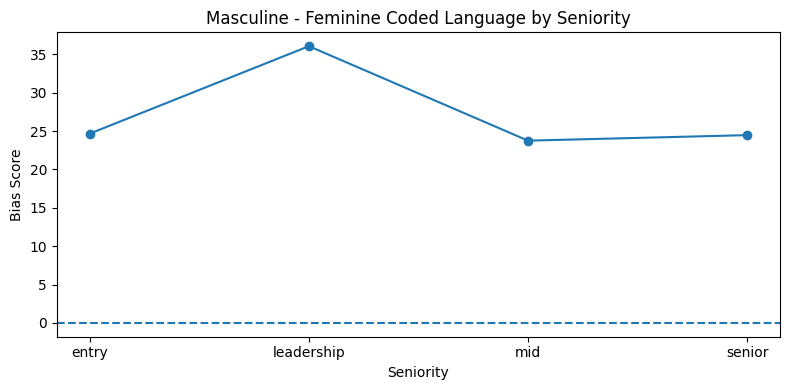

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(summary["seniority"], summary["bias_score"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Masculine - Feminine Coded Language by Seniority")
plt.xlabel("Seniority")
plt.ylabel("Bias Score")
plt.tight_layout()
plt.show()

The lexicon-based method may introduce some researcher bias because it relies on predefined sets of masculine-coded and feminine-coded words. These classifications are based on social and cultural stereotypes rather than inherent linguistic properties. However, the word lists used in this analysis are derived from prior research on gendered language in job advertisements, which experimentally validated these associations. Therefore, while the approach has limitations, it remains a widely accepted method for studying gender-coded language patterns in organizational communication.

The first graph compares the frequency of masculine-coded and feminine-coded words in job postings across different seniority levels. The values are normalized as words per 1000 tokens.

From the plot we observe:

Masculine-coded language appears consistently more frequently than feminine-coded language across all seniority levels.

The highest use of masculine-coded language occurs in leadership roles, reaching roughly 44 words per 1000 tokens.

Entry, mid, and senior roles all show similar levels of masculine-coded language, around 41–42 words per 1000 tokens.

Feminine-coded language is significantly lower across all levels, ranging roughly between 8 and 18 words per 1000 tokens.

A particularly notable pattern is that leadership roles contain the lowest amount of feminine-coded language, suggesting that leadership job descriptions emphasize traits traditionally associated with masculine stereotypes such as independence, competitiveness, and authority.

The second graph shows a bias score, calculated as:

Bias Score = Masculine-coded frequency − Feminine-coded frequency

This value measures the degree of masculine bias in the language used in job postings.

Observations:

All seniority levels have positive bias scores, meaning masculine-coded words appear more frequently than feminine-coded words in all groups.

The largest bias occurs in leadership roles, with a bias score of approximately 36.

Entry-level, mid-level, and senior roles have slightly lower but still significant bias scores, around 23–25.

This indicates that while masculine-coded language is common across the entire dataset, it becomes particularly dominant in leadership job descriptions.
